In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [11]:

# 1. Cargar el dataset
df = pd.read_csv('df_preparado_modelado.csv')

# --- TRUCO: Verifica que los nombres coinciden ---
print("Columnas detectadas en el CSV:", df.columns.tolist())

# Asegurar que las columnas categóricas se traten como tales
categorical_cols = ['Provincia', 'tipo_abc', 'codigo_articulo', 'modalidad']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 2. Definir Features (X) y Target (y) con los nombres CORREGIDOS
features = [
    'year', 'week', 'Provincia', 'tipo_abc', 'codigo_articulo', 
    'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 
    'clima_precip', 'clima_viento', 
    'ventas_lag_semanal',  # <--- Cambiado de ventas_lag1 a ventas_lag_semanal
    'ventas_lag_mensual'
]
target = 'unidades'

# 3. Split Temporal
test_threshold_year = 2024
test_threshold_week = 30

train = df[(df['year'] < test_threshold_year) | ((df['year'] == test_threshold_year) & (df['week'] < test_threshold_week))]
test = df[(df['year'] == test_threshold_year) & (df['week'] >= test_threshold_week)]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 4. Configurar y Entrenar el Modelo
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

print("Entrenando modelo...")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# 5. Predicciones y Métricas
preds = model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

# 6. Resultado Final Agregado por Semana
test['prediccion'] = preds
resultado_semanal = test.groupby('anio_semana')[['unidades', 'prediccion']].sum().reset_index()
print("\n--- RESUMEN DE PREDICCIÓN SEMANAL ---")
print(resultado_semanal)

Columnas detectadas en el CSV: ['anio_semana', 'Provincia', 'tipo_abc', 'codigo_articulo', 'unidades', 'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 'clima_precip', 'clima_viento', 'year', 'week', 'ventas_lag_semanal', 'ventas_lag_mensual']
Entrenando modelo...
[0]	validation_0-rmse:1.00783
[50]	validation_0-rmse:0.81599
[100]	validation_0-rmse:0.84165
[150]	validation_0-rmse:0.84736
[200]	validation_0-rmse:0.85906
[250]	validation_0-rmse:0.90339
[300]	validation_0-rmse:0.91412
[350]	validation_0-rmse:0.92931
[400]	validation_0-rmse:0.94834
[450]	validation_0-rmse:0.95338
[499]	validation_0-rmse:0.96785

MAE: 0.0645
R2 Score: 0.1140

--- RESUMEN DE PREDICCIÓN SEMANAL ---
  anio_semana  unidades   prediccion
0     2024-30    5937.0  5954.735352
1     2024-31    3943.0  4281.375977
2     2024-32    4116.0  4485.776855
3     2024-33    1970.0  3273.311279
4     2024-34    2698.0  3201.829590
5     2024-35    2339.0  3324.831543
6     2024-36    3657.0  3524.468994
7     2024-37    

C:\Users\gogar\AppData\Local\Temp\ipykernel_2376\1956453228.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediccion'] = preds


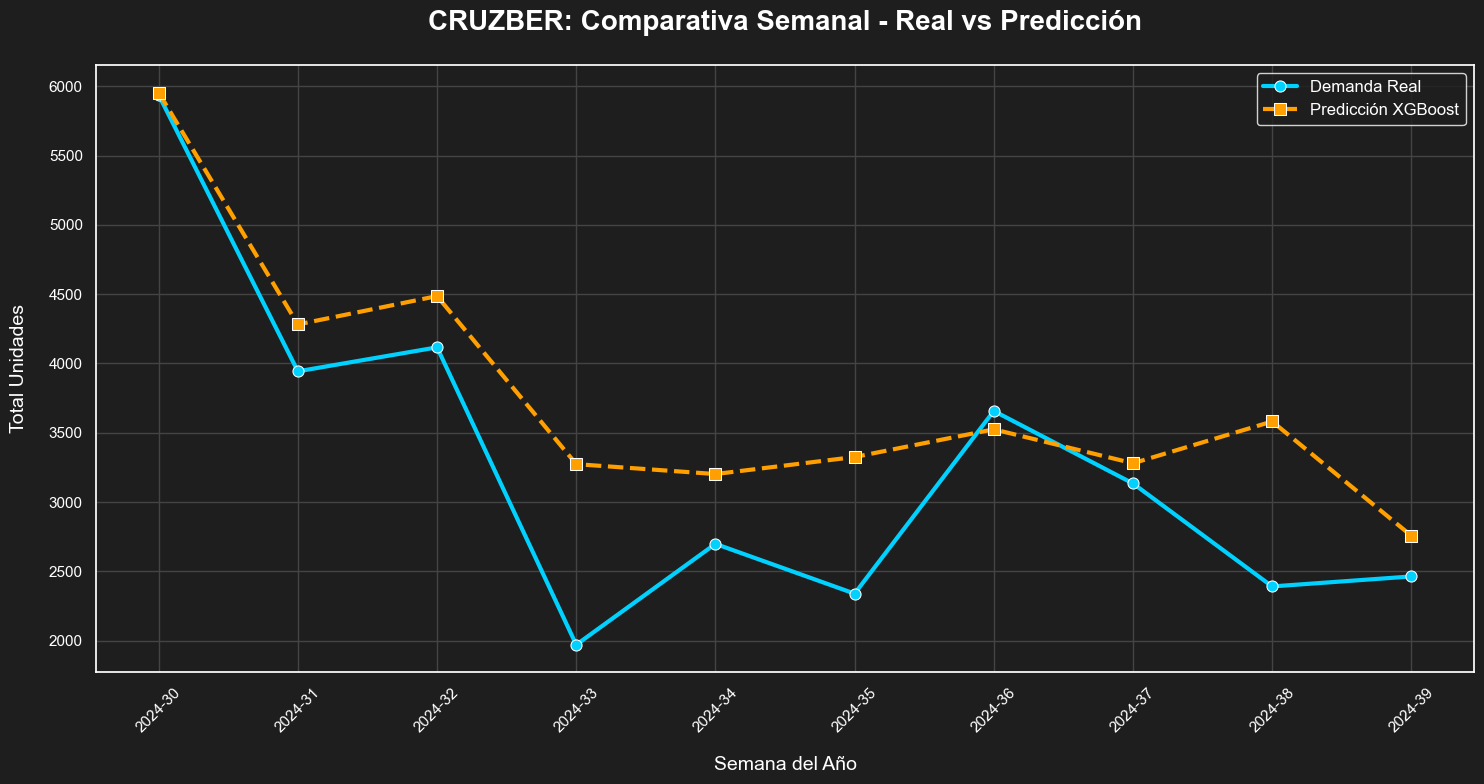

In [12]:
# 1. Configuración de estilo "Professional Dark"
sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#1e1e1e'
plt.rcParams['axes.facecolor'] = '#1e1e1e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#444444'

# 2. Preparación de los datos para la gráfica
# Agrupamos por semana para ver la tendencia general de la empresa
# Nota: 'test' es el dataframe que contiene tus resultados y la columna 'prediccion'
grafico_df = test.groupby('anio_semana').agg({
    'unidades': 'sum',
    'prediccion': 'sum'
}).reset_index()

# Ordenamos cronológicamente
grafico_df['sort_key'] = grafico_df['anio_semana'].apply(lambda x: int(x.split('-')[0])*100 + int(x.split('-')[1]))
grafico_df = grafico_df.sort_values('sort_key')

# 3. Creación del gráfico
plt.figure(figsize=(15, 8))

# Línea de Ventas Reales (Cian)
sns.lineplot(data=grafico_df, x='anio_semana', y='unidades', 
             label='Demanda Real', color='#00d1ff', linewidth=3, marker='o', markersize=8)

# Línea de Predicción (Naranja)
sns.lineplot(data=grafico_df, x='anio_semana', y='prediccion', 
             label='Predicción XGBoost', color='#ff9f00', linewidth=3, marker='s', markersize=8, linestyle='--')

# Personalización de etiquetas
plt.title('CRUZBER: Comparativa Semanal - Real vs Predicción', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Semana del Año', fontsize=14, labelpad=15)
plt.ylabel('Total Unidades', fontsize=14, labelpad=15)
plt.xticks(rotation=45)
plt.legend(fontsize=12, facecolor='#1e1e1e', edgecolor='white')

# Ajuste final y guardado
plt.tight_layout()
plt.savefig('visualizacion_resultados_cruzber.png', dpi=300)
# plt.show() # Descomenta esta línea si quieres verlo directamente en el notebook